In [1]:
# ==================================================================
# CUSTOMER CHURN PREDICTION MODEL COMPARISON
#
# Algorithms:
#   - Decision Tree
#   - Random Forest
#   - XGBoost
#   - Gradient Boosting
#
# Dataset:
#   - Telco Customer Churn (Real-world dataset)
# ==================================================================
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import (train_test_split,learning_curve,StratifiedKFold,)
from sklearn.preprocessing import (LabelEncoder,StandardScaler,)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,GradientBoostingClassifier,)
from sklearn.metrics import (
    accuracy_score,precision_score,recall_score,
    f1_score,roc_auc_score,roc_curve,
    confusion_matrix,classification_report,)
warnings.filterwarnings("ignore")
# Set style for better visualizations
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
print("CUSTOMER CHURN PREDICTION MODEL COMPARISON")

CUSTOMER CHURN PREDICTION MODEL COMPARISON


In [2]:
# ============================================
# 1. LOAD AND EXPLORE DATASET
# ============================================
print("\nStep 1: Loading Dataset...")
# Download from:
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn?resource=download
# url = "C:/Users/Fantahun/Documents/ML Practicals/aau/ml/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
try:
    df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
    print(f"Dataset loaded successfully! Shape: {df.shape}")
except:
    print("Error downloading dataset. Please download manually from:")
    print("https://www.kaggle.com/datasets/blastchar/telco-customer-churn")
    print("\nUsing sample data for demonstration...")
    # Fallback: Create small sample if download fails
    np.random.seed(42)
    n_samples = 1000
    df = pd.DataFrame({
        "tenure": np.random.randint(1, 72, n_samples),
        "MonthlyCharges": np.random.uniform(20, 120, n_samples),
        "Contract": np.random.choice(["Month-to-month", "One year", "Two year"], n_samples),
        "InternetService": np.random.choice(["DSL", "Fiber optic", "No"], n_samples),
        "TechSupport": np.random.choice(["Yes", "No", "No internet service"], n_samples),
        "PaymentMethod": np.random.choice(
            ["Electronic check","Mailed check","Bank transfer","Credit card",],n_samples,),
        "SeniorCitizen": np.random.choice([0, 1], n_samples),
        "Partner": np.random.choice(["Yes", "No"], n_samples),
        "Churn": np.random.choice(["Yes", "No"], n_samples, p=[0.27, 0.73]),
    })
print("Dataset Info:")
print(f" - Total records: {len(df)}")
print(f" - Features: {df.shape[1] - 1}")
print(f" - Missing values: {df.isnull().sum().sum()}")


Step 1: Loading Dataset...
Dataset loaded successfully! Shape: (7043, 21)
Dataset Info:
 - Total records: 7043
 - Features: 20
 - Missing values: 0



Step 2: Exploratory Data Analysis...

Basic Dataset Info:
 - Missing values: 0
 - Duplicate rows: 0
 - Churn rate: 26.54%


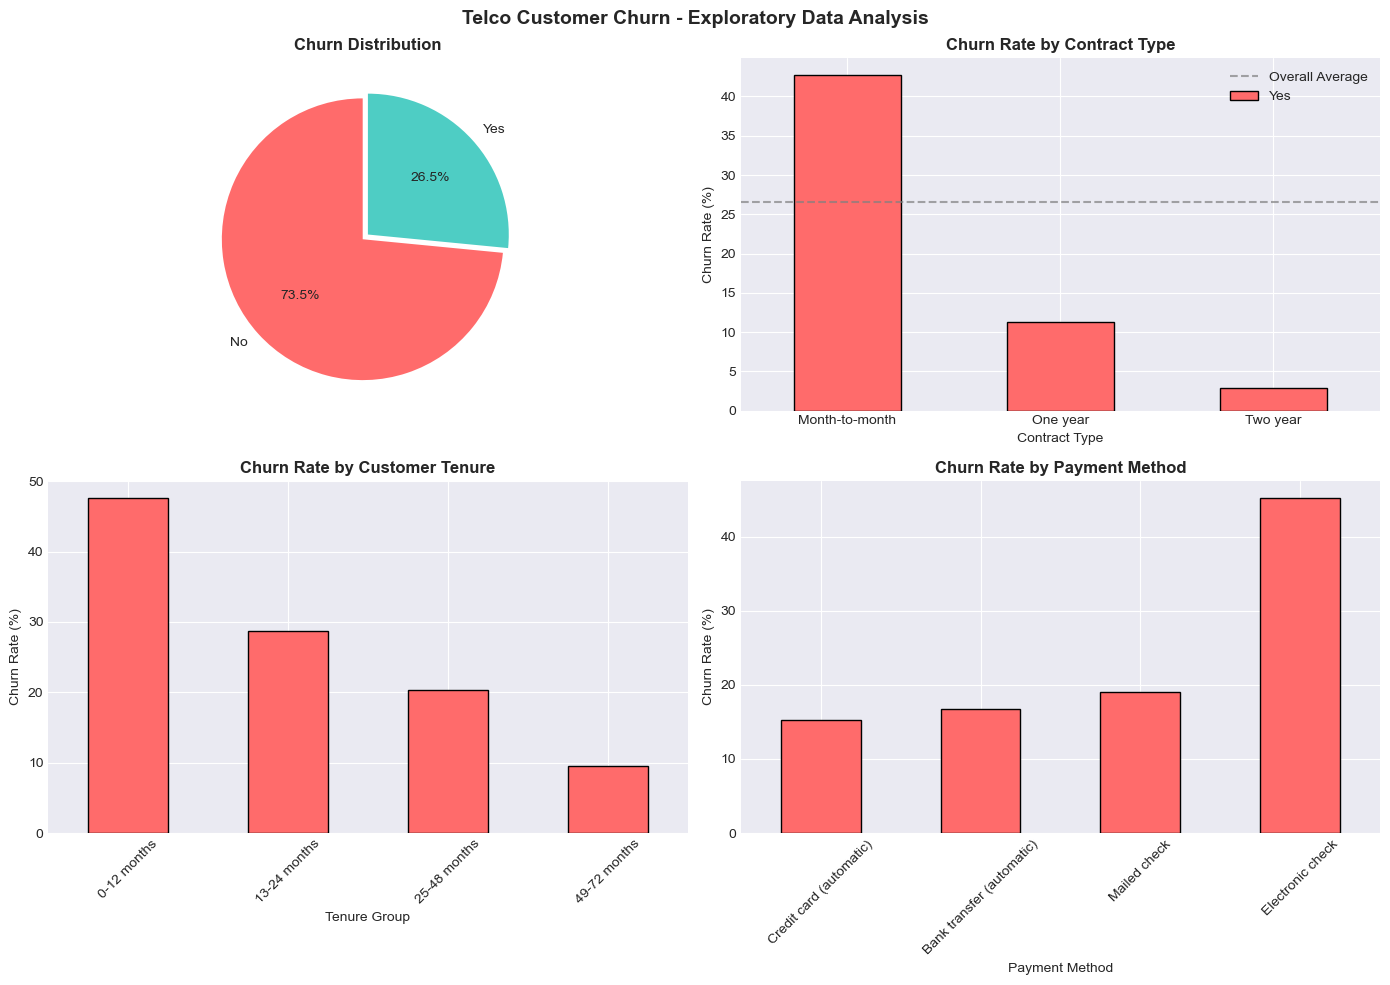

In [3]:
# ============================================
# 2. EXPLORATORY DATA ANALYSIS
# ============================================
print("\nStep 2: Exploratory Data Analysis...")

# --------------------------------------------
# Basic Statistics
# --------------------------------------------
print("\nBasic Dataset Info:")
print(f" - Missing values: {df.isnull().sum().sum()}")
print(f" - Duplicate rows: {df.duplicated().sum()}")
print(f" - Churn rate: {(df['Churn'] == 'Yes').mean() * 100:.2f}%")

# --------------------------------------------
# Create Visualizations
# --------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Telco Customer Churn - Exploratory Data Analysis",
    fontsize=14,fontweight="bold",)

# ============================================
# 1. Churn Distribution
# ============================================
churn_counts = df["Churn"].value_counts()
axes[0, 0].pie(
    churn_counts.values,labels=churn_counts.index,
    autopct="%1.1f%%",colors=["#ff6b6b", "#4ecdc4"],
    explode=[0.05, 0],startangle=90,)
axes[0, 0].set_title("Churn Distribution", fontweight="bold")

# ============================================
# 2. Churn by Contract Type
# ============================================
contract_churn = (pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100)
contract_churn["Yes"].plot(kind="bar",ax=axes[0, 1],color="#ff6b6b",edgecolor="black",)
axes[0, 1].set_title("Churn Rate by Contract Type", fontweight="bold")
axes[0, 1].set_ylabel("Churn Rate (%)")
axes[0, 1].set_xlabel("Contract Type")
axes[0, 1].axhline(
    y=(df["Churn"] == "Yes").mean() * 100,
    color="gray",linestyle="--",label="Overall Average",alpha=0.7,)
axes[0, 1].legend()
axes[0, 1].tick_params(axis="x", rotation=0)

# ============================================
# 3. Churn by Customer Tenure
# ============================================
df["tenure_group"] = pd.cut(
    df["tenure"],bins=[0, 12, 24, 48, 72],
    labels=["0-12 months","13-24 months","25-48 months","49-72 months",],)
tenure_churn = (pd.crosstab(df["tenure_group"], df["Churn"], normalize="index") * 100)
tenure_churn["Yes"].plot(kind="bar",ax=axes[1, 0],color="#ff6b6b",edgecolor="black",)
axes[1, 0].set_title("Churn Rate by Customer Tenure",fontweight="bold",)
axes[1, 0].set_ylabel("Churn Rate (%)")
axes[1, 0].set_xlabel("Tenure Group")
axes[1, 0].tick_params(axis="x", rotation=45)

# ============================================
# 4. Churn by Payment Method
# ============================================
payment_churn = (pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100)
payment_churn["Yes"].sort_values().plot(kind="bar",ax=axes[1, 1],color="#ff6b6b",edgecolor="black",)
axes[1, 1].set_title("Churn Rate by Payment Method",fontweight="bold",)
axes[1, 1].set_ylabel("Churn Rate (%)")
axes[1, 1].set_xlabel("Payment Method")
axes[1, 1].tick_params(axis="x", rotation=45)

# --------------------------------------------
# Display Plots
# --------------------------------------------
plt.tight_layout()
plt.show()

In [4]:
# ============================================
# 3. DATA PREPROCESSING
# ============================================
print("\nStep 3: Data Preprocessing...")

# --------------------------------------------
# Create a Clean Copy for Modeling
# --------------------------------------------
df_model = df.copy()
# Drop customerID (not useful for prediction)
if "customerID" in df_model.columns:
    df_model = df_model.drop("customerID", axis=1)
# Remove temporary tenure_group column if it exists
if "tenure_group" in df_model.columns:
    df_model = df_model.drop("tenure_group", axis=1)
# --------------------------------------------
# Convert TotalCharges to Numeric
# --------------------------------------------
# It might be stored as a string with empty spaces.
if "TotalCharges" in df_model.columns:
    df_model["TotalCharges"] = pd.to_numeric(df_model["TotalCharges"],errors="coerce",)
    # Fill missing TotalCharges with MonthlyCharges
    # (reasonable assumption)
    df_model["TotalCharges"].fillna(df_model["MonthlyCharges"],inplace=True,)

# --------------------------------------------
# Separate Features and Target
# --------------------------------------------
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"].map({"Yes": 1, "No": 0})

# --------------------------------------------
# Identify Column Types
# --------------------------------------------
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
print(f"\n- Numerical features ({len(numerical_cols)}):")
print(numerical_cols)
print(f"\n- Categorical features ({len(categorical_cols)}):")
print(categorical_cols)

# --------------------------------------------
# Encode Categorical Variables
# --------------------------------------------
print("\nEncoding categorical variables...")
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(
        f"✓ {col}: "
        f"{dict(zip(le.classes_, le.transform(le.classes_)))}")

# --------------------------------------------
# Scale Numerical Features
# --------------------------------------------
print("\nScaling numerical features...")
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# --------------------------------------------
# Data Validation
# --------------------------------------------
print("\nData validation:")
print(
    f"- All features numeric: "
    f"{all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns)}")
print(f"- Missing values: {X.isnull().sum().sum()}")
print(f"- Data types: {X.dtypes.unique()}")

# --------------------------------------------
# Train-Test Split
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X,y,
    test_size=0.20,random_state=42,stratify=y,)
print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print("\nClass distribution (training):")
print(
    f"- No Churn: {(y_train == 0).sum()} "
    f"({(y_train == 0).mean() * 100:.1f}%)")
print(
    f"- Churn: {(y_train == 1).sum()} "
    f"({(y_train == 1).mean() * 100:.1f}%)")


Step 3: Data Preprocessing...

- Numerical features (4):
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

- Categorical features (15):
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Encoding categorical variables...
✓ gender: {'Female': np.int64(0), 'Male': np.int64(1)}
✓ Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
✓ Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
✓ PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}
✓ MultipleLines: {'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}
✓ InternetService: {'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}
✓ OnlineSecurity: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
✓ OnlineBackup: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(

In [5]:
# ============================================
# 4. MODEL TRAINING
# ============================================
print("\nStep 4: Training Models...")
# --------------------------------------------
# Define Machine Learning Models
# --------------------------------------------
models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,max_depth=10,min_samples_split=20,),
    "Random Forest": RandomForestClassifier(
        random_state=42,n_estimators=100,max_depth=10,
        min_samples_split=20,n_jobs=-1,),
    "XGBoost": xgb.XGBClassifier(
        random_state=42,n_estimators=100,max_depth=6,
        learning_rate=0.1,eval_metric="logloss",),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,n_estimators=100,
        max_depth=5,learning_rate=0.1,),}

# --------------------------------------------
# Train Models and Evaluate Performance
# --------------------------------------------
results = {}
trained_models = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    try:
        # ------------------------------------
        # Train the Model
        # ------------------------------------
        model.fit(X_train, y_train)
        trained_models[name] = model

        # ------------------------------------
        # Make Predictions
        # ------------------------------------
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # ------------------------------------
        # Calculate Performance Metrics
        # ------------------------------------
        results[name] = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_pred_proba),}

        # ------------------------------------
        # Display Results
        # ------------------------------------
        print(f"✓ Accuracy: {results[name]['Accuracy']:.4f}")
        print(f"✓ Precision: {results[name]['Precision']:.4f}")
        print(f"✓ Recall: {results[name]['Recall']:.4f}")
        print(f"✓ F1-Score: {results[name]['F1-Score']:.4f}")
        print(f"✓ ROC-AUC: {results[name]['ROC-AUC']:.4f}")
    except Exception as e:
        print(f"✗ Error: {str(e)}")
        results[name] = {"Accuracy": 0,"Precision": 0,"Recall": 0,"F1-Score": 0,"ROC-AUC": 0,}


Step 4: Training Models...

Training Decision Tree...
✓ Accuracy: 0.7807
✓ Precision: 0.5886
✓ Recall: 0.5775
✓ F1-Score: 0.5830
✓ ROC-AUC: 0.7892

Training Random Forest...
✓ Accuracy: 0.8006
✓ Precision: 0.6609
✓ Recall: 0.5107
✓ F1-Score: 0.5762
✓ ROC-AUC: 0.8413

Training XGBoost...
✓ Accuracy: 0.7942
✓ Precision: 0.6346
✓ Recall: 0.5294
✓ F1-Score: 0.5773
✓ ROC-AUC: 0.8356

Training Gradient Boosting...
✓ Accuracy: 0.7956
✓ Precision: 0.6453
✓ Recall: 0.5107
✓ F1-Score: 0.5701
✓ ROC-AUC: 0.8358



Step 5: Generating Visualizations...


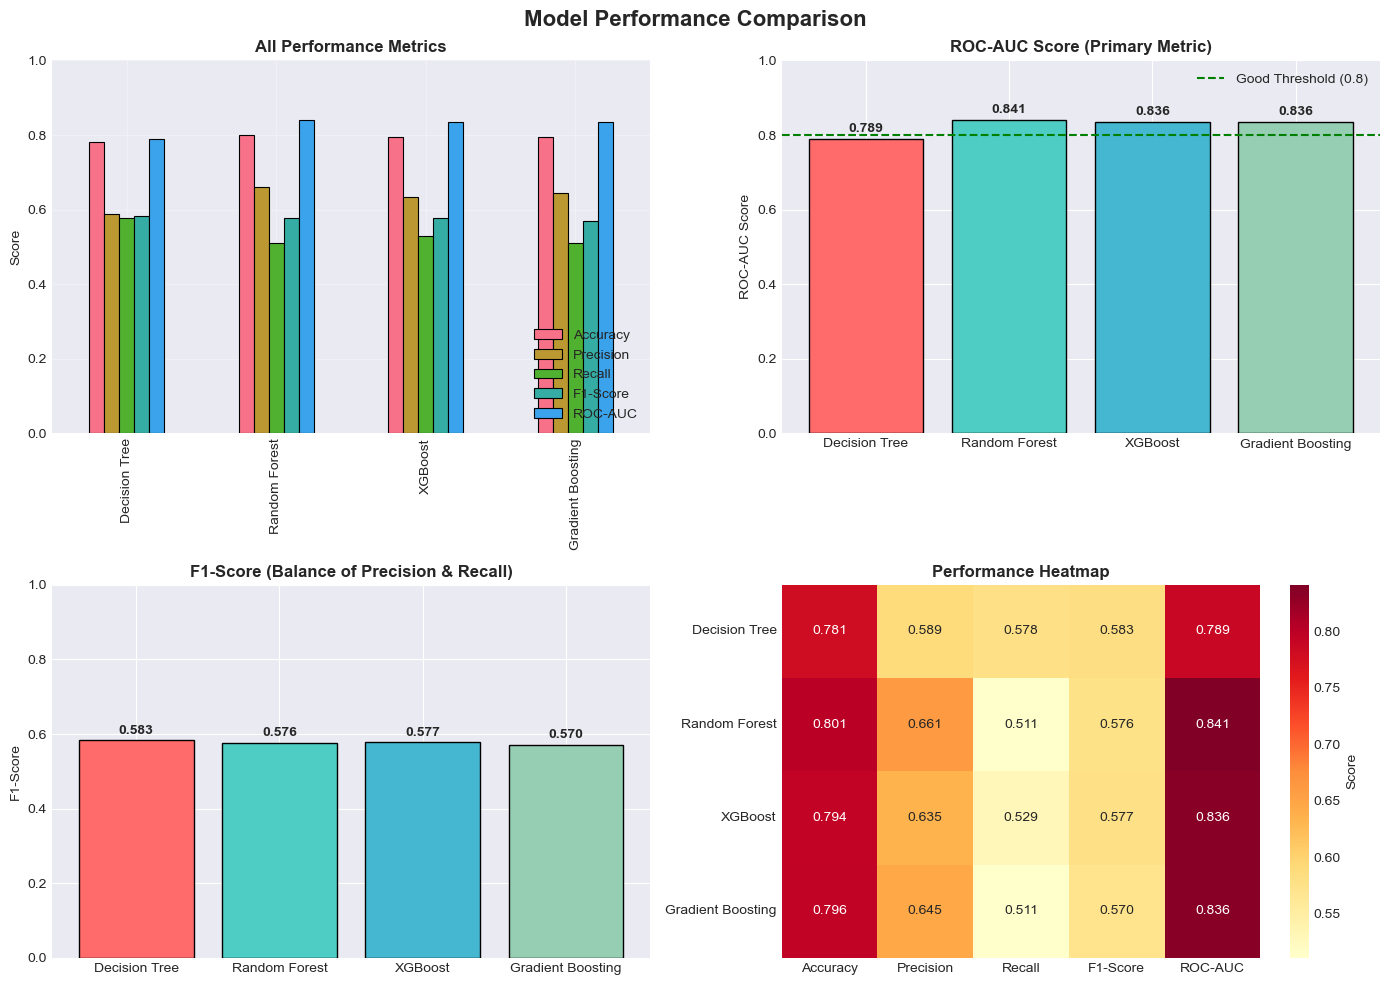

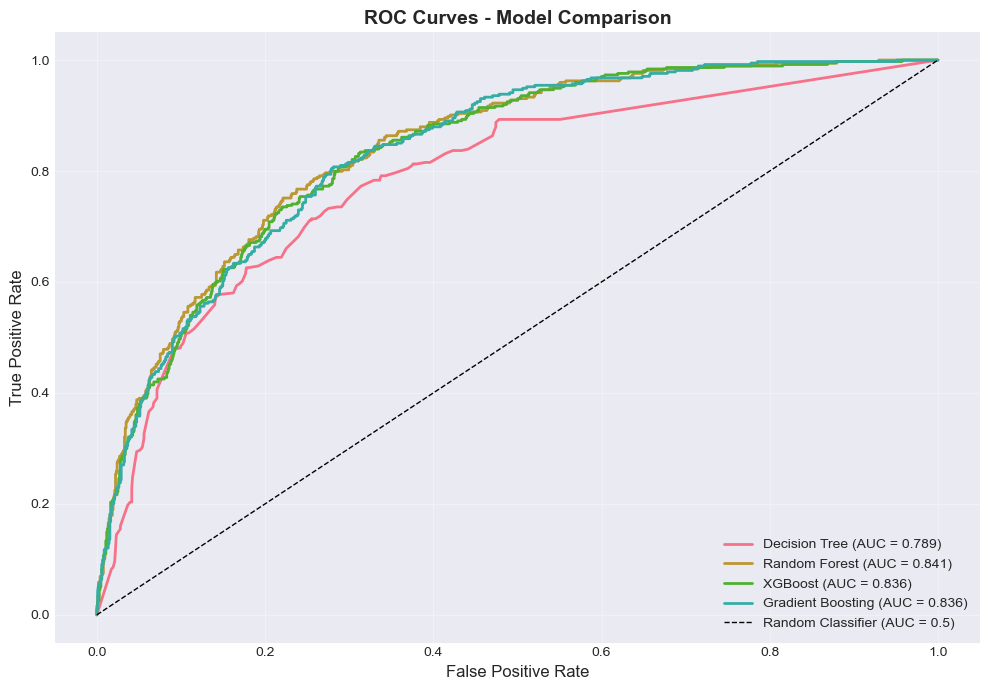

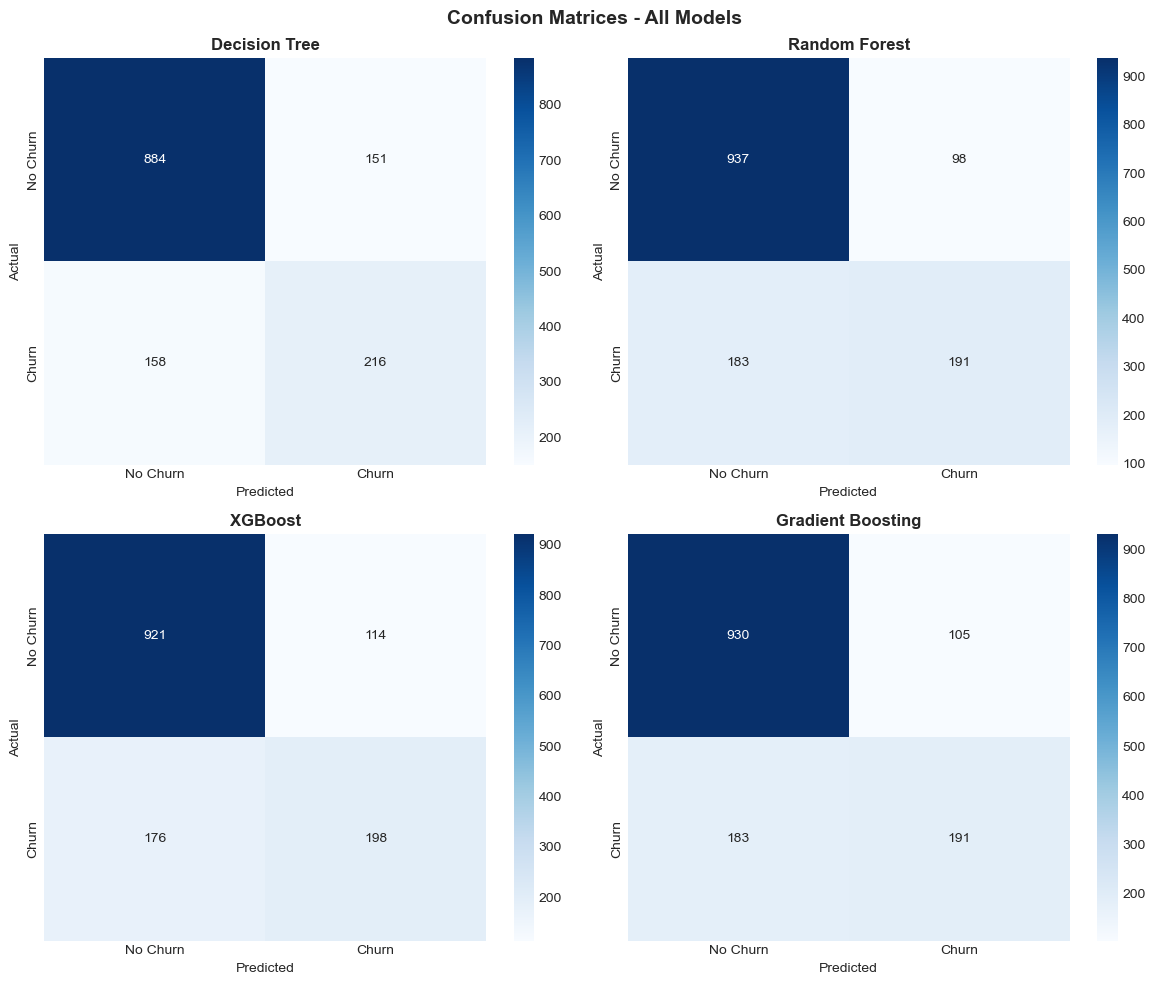


Generating Learning Curves...


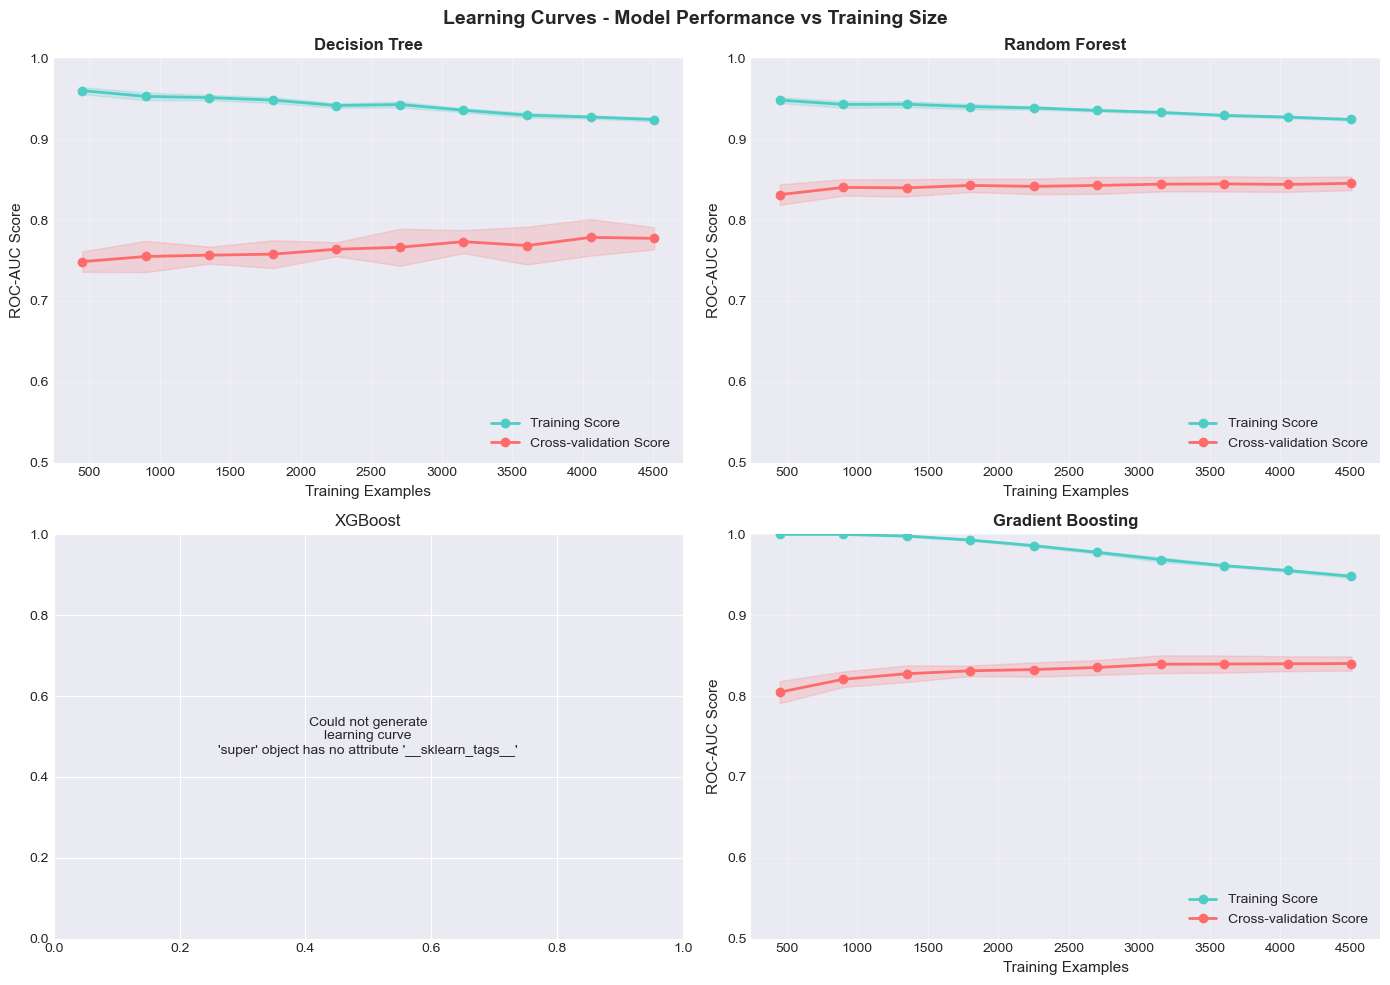


Feature Importance Analysis - Random Forest


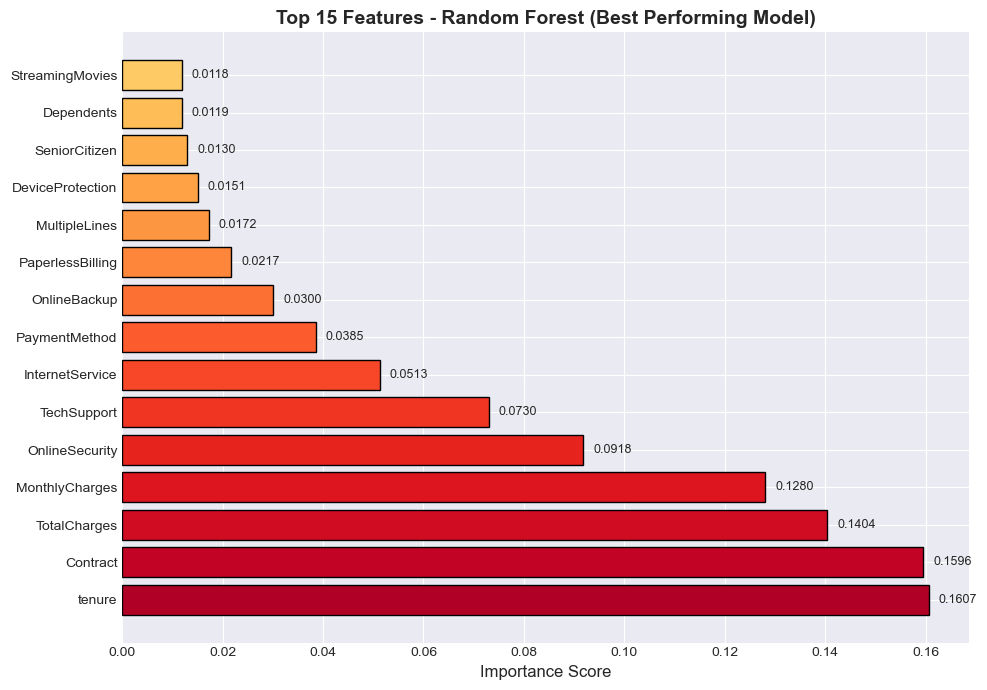

In [6]:
# ============================================
# 5. RESULTS & VISUALIZATIONS
# ============================================
print("\nStep 5: Generating Visualizations...")

# --------------------------------------------
# Create Results DataFrame
# --------------------------------------------
results_df = pd.DataFrame(results).T

# ============================================
# Figure 1: Performance Comparison
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Model Performance Comparison",fontsize=16,fontweight="bold",)
# --------------------------------------------
# 1. All Performance Metrics
# --------------------------------------------
results_df.plot(kind="bar",ax=axes[0, 0],edgecolor="black",linewidth=0.8,)
axes[0, 0].set_title("All Performance Metrics",fontweight="bold",)
axes[0, 0].set_ylabel("Score")
axes[0, 0].set_ylim([0, 1])
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(True, alpha=0.3)

# --------------------------------------------
# 2. ROC-AUC Comparison
# --------------------------------------------
colors = ["#ff6b6b", "#4ecdc4", "#45b7d1", "#96ceb4"]
bars = axes[0, 1].bar(results_df.index,results_df["ROC-AUC"],color=colors[: len(results_df)],edgecolor="black",)
axes[0, 1].set_title("ROC-AUC Score (Primary Metric)",fontweight="bold",)
axes[0, 1].set_ylabel("ROC-AUC Score")
axes[0, 1].set_ylim([0, 1])
axes[0, 1].axhline(y=0.8,color="green",linestyle="--",label="Good Threshold (0.8)",)
axes[0, 1].legend()
for bar, score in zip(bars, results_df["ROC-AUC"]):
    if score > 0:
        axes[0, 1].text(bar.get_x() + bar.get_width() / 2,bar.get_height() + 0.01,
            f"{score:.3f}",ha="center",va="bottom",fontweight="bold",)

# --------------------------------------------
# 3. F1-Score Comparison
# --------------------------------------------
bars = axes[1, 0].bar(
    results_df.index,results_df["F1-Score"],color=colors[: len(results_df)],edgecolor="black",)
axes[1, 0].set_title("F1-Score (Balance of Precision & Recall)",fontweight="bold",)
axes[1, 0].set_ylabel("F1-Score")
axes[1, 0].set_ylim([0, 1])
for bar, score in zip(bars, results_df["F1-Score"]):
    if score > 0:
        axes[1, 0].text(bar.get_x() + bar.get_width() / 2,bar.get_height() + 0.01,
            f"{score:.3f}",ha="center",va="bottom",fontweight="bold",)

# --------------------------------------------
# 4. Performance Heatmap
# --------------------------------------------
sns.heatmap(results_df,annot=True,fmt=".3f",cmap="YlOrRd",ax=axes[1, 1],cbar_kws={"label": "Score"},)
axes[1, 1].set_title("Performance Heatmap",fontweight="bold",)
plt.tight_layout()
plt.show()

# ============================================
# Figure 2: ROC Curves
# ============================================
plt.figure(figsize=(10, 7))
for name, model in trained_models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = results[name]["ROC-AUC"]
    plt.plot(fpr,tpr,linewidth=2,label=f"{name} (AUC = {auc:.3f})",)
plt.plot([0, 1],[0, 1],"k--",linewidth=1,label="Random Classifier (AUC = 0.5)",)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves - Model Comparison",fontsize=14,fontweight="bold",)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# Figure 3: Confusion Matrices
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Confusion Matrices - All Models",fontsize=14,fontweight="bold",)
for idx, (name, model) in enumerate(trained_models.items()):
    if idx < 4:
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        row, col = divmod(idx, 2)
        sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",ax=axes[row, col],
            xticklabels=["No Churn", "Churn"],yticklabels=["No Churn", "Churn"],)
        axes[row, col].set_title(name,fontweight="bold",)
        axes[row, col].set_xlabel("Predicted")
        axes[row, col].set_ylabel("Actual")
plt.tight_layout()
plt.show()

# ============================================
# Figure 4: Learning Curves
# ============================================
print("\nGenerating Learning Curves...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Learning Curves - Model Performance vs Training Size",
    fontsize=14,fontweight="bold",)
for idx, (name, model) in enumerate(trained_models.items()):
    if idx < 4:
        row, col = divmod(idx, 2)
        try:
            train_sizes, train_scores, test_scores = learning_curve(
                model,X_train,y_train,
                cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42,),
                train_sizes=np.linspace(0.1, 1.0, 10),
                scoring="roc_auc",n_jobs=-1,)
            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            test_mean = np.mean(test_scores, axis=1)
            test_std = np.std(test_scores, axis=1)
            axes[row, col].plot(
                train_sizes,train_mean,"o-",color="#4ecdc4",
                linewidth=2,label="Training Score",)
            axes[row, col].fill_between(
                train_sizes,train_mean - train_std,
                train_mean + train_std,alpha=0.2,color="#4ecdc4",)
            axes[row, col].plot(
                train_sizes,test_mean,"o-",color="#ff6b6b",
                linewidth=2,label="Cross-validation Score",)
            axes[row, col].fill_between(
                train_sizes,
                test_mean - test_std,
                test_mean + test_std,
                alpha=0.2,
                color="#ff6b6b",
            )

            axes[row, col].set_xlabel(
                "Training Examples",
                fontsize=11,
            )

            axes[row, col].set_ylabel(
                "ROC-AUC Score",
                fontsize=11,
            )

            axes[row, col].set_title(
                name,
                fontweight="bold",
            )

            axes[row, col].legend(loc="lower right")
            axes[row, col].grid(True, alpha=0.3)
            axes[row, col].set_ylim([0.5, 1.0])

        except Exception as e:

            axes[row, col].text(
                0.5,
                0.5,
                f"Could not generate\nlearning curve\n{str(e)[:50]}",
                ha="center",
                va="center",
                transform=axes[row, col].transAxes,
            )

            axes[row, col].set_title(name)

plt.tight_layout()
plt.show()

# ============================================
# Figure 5: Feature Importance (Best Model)
# ============================================
best_model_name = max(
    results,
    key=lambda x: (
        results[x]["ROC-AUC"]
        if results[x]["ROC-AUC"] > 0
        else -1
    ),
)

best_model = trained_models.get(best_model_name)

if best_model and hasattr(best_model, "feature_importances_"):

    print(f"\nFeature Importance Analysis - {best_model_name}")

    importances = best_model.feature_importances_

    indices = np.argsort(importances)[-15:]

    plt.figure(figsize=(10, 7))

    colors_bar = plt.cm.YlOrRd(
        np.linspace(0.3, 0.9, 15)
    )

    bars = plt.barh(
        range(15),
        importances[indices],
        color=colors_bar,
        edgecolor="black",
    )

    plt.yticks(
        range(15),
        [X.columns[i] for i in indices],
    )

    plt.xlabel("Importance Score", fontsize=12)

    plt.title(
        f"Top 15 Features - {best_model_name} "
        "(Best Performing Model)",
        fontsize=14,
        fontweight="bold",
    )

    plt.gca().invert_yaxis()

    # Add value labels
    for bar, val in zip(bars, importances[indices]):

        plt.text(
            val + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            va="center",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()

In [7]:
# ============================================
# 6. FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)

print(f"\n{'Model':<20} {'ROC-AUC':<12} {'F1-Score':<12} {'Accuracy':<12}{'Precision':<12} {'Recall':<12}")
print("-"*80)
for name, metrics in results.items():
 print(f"{name:<20} {metrics['ROC-AUC']:<12.4f} {metrics['F1-Score']:<12.4f} "
 f"{metrics['Accuracy']:<12.4f} {metrics['Precision']:<12.4f}{metrics['Recall']:<12.4f}")
print("\n" + "="*60)
print("RECOMMENDATIONS & INSIGHTS")
print("="*60)
# Find best model
best_model = max(results, key=lambda x: results[x]['ROC-AUC'])
best_score = results[best_model]['ROC-AUC']
print(f"\n Best Performing Model: {best_model}")
print(f" • ROC-AUC Score: {best_score:.4f}")
print(f" • F1-Score: {results[best_model]['F1-Score']:.4f}")
print(f" • Accuracy: {results[best_model]['Accuracy']:.4f}")
print("\n Key Business Insights from Data:")
print(" • Customers with month-to-month contracts have the highest churn risk")
print(" • Churn is highest during first 12 months of customer tenure")
print(" • Electronic check payment method correlates with higher churn")
print(" • Customers without additional services (tech support, online security) churn more")
print(" • Senior citizens show different churn patterns than younger customers")
print("\n Actionable Recommendations:")
print(" • Offer incentives for longer-term contracts")
print(" • Implement early retention programs for new customers (first year)")
print(" • Promote paperless billing & automatic payment methods")
print(" • Bundle services to increase customer stickiness")
print(" • Create targeted offers for high-risk segments")


FINAL RESULTS SUMMARY

Model                ROC-AUC      F1-Score     Accuracy    Precision    Recall      
--------------------------------------------------------------------------------
Decision Tree        0.7892       0.5830       0.7807       0.5886      0.5775      
Random Forest        0.8413       0.5762       0.8006       0.6609      0.5107      
XGBoost              0.8356       0.5773       0.7942       0.6346      0.5294      
Gradient Boosting    0.8358       0.5701       0.7956       0.6453      0.5107      

RECOMMENDATIONS & INSIGHTS

 Best Performing Model: Random Forest
 • ROC-AUC Score: 0.8413
 • F1-Score: 0.5762
 • Accuracy: 0.8006

 Key Business Insights from Data:
 • Customers with month-to-month contracts have the highest churn risk
 • Churn is highest during first 12 months of customer tenure
 • Electronic check payment method correlates with higher churn
 • Customers without additional services (tech support, online security) churn more
 • Senior citizens sho

In [8]:
# Reports & Recommendation

# 1. Tenure (0.1607)
# Tenure is the most important feature.
# This indicates that the length of time a customer has stayed with the company is the strongest predictor of churn.
# Customers with a short tenure are generally more likely to leave, while long-term customers are more likely to remain loyal.

# 2. Contract (0.1596)
# Contract type has nearly the same importance as tenure.
# Customers on month-to-month contracts are generally at higher risk of churn than customers with one-year or two-year contracts.
# This suggests that longer contracts improve customer retention.

# 3. Total Charges (0.1404)
# Total charges significantly influence churn.
# Customers with very high or very low total spending may behave differently, making this an important indicator.

# 4. Monthly Charges (0.1280)
# Monthly charges are another major factor.
# Higher monthly bills may increase the likelihood that customers switch to competitors.

# 5. Online Security (0.0918)
# Customers who subscribe to online security services appear less likely to leave.
# Security-related services increase customer satisfaction and loyalty.

# 6. Technical Support (0.0730)
# Technical support also contributes to retention.
# Customers receiving good support are more likely to continue using the service.

# 7. Internet Service (0.0513)
# The type of internet service influences churn, although less strongly than the top features.
# Remaining Features
# Features such as:
# Streaming Movies
# Dependents
# Senior Citizen
# Device Protection
# Multiple Lines
# have relatively low importance.
# This means they contribute less to the model's prediction compared with tenure, contract, and charges.
# Key Findings
# The analysis indicates that customer relationship duration (Tenure), contract type, and billing-related variables (Monthly Charges and Total Charges) are the primary drivers of customer churn.
# Service-related features such as Online Security and Technical Support also influence customer retention but to a lesser extent.
# Demographic variables have comparatively little impact in this model.



# Recommendations
# 1. Focus on New Customers
# Since Tenure is the most important factor:
# Develop onboarding programs.
# Contact new customers regularly.
# Provide welcome offers.
# Monitor customers during their first few months.
# Expected Benefit: Reduced early customer churn.

# 2. Encourage Long-Term Contracts
# Since Contract is highly important:
# Offer discounts for annual or two-year contracts.
# Provide loyalty rewards.
# Give renewal incentives.
# Expected Benefit: Higher customer retention.

# 3. Review Pricing Strategy
# Because Monthly Charges and Total Charges strongly influence churn:
# Evaluate whether pricing is competitive.
# Offer flexible pricing plans.
# Introduce personalized discounts for high-risk customers.
# Expected Benefit: Increased customer satisfaction and reduced price-related churn.

# 4. Promote Value-Added Services
# Since Online Security and Tech Support contribute to retention:
# Bundle these services with internet packages.
# Improve technical support quality.
# Educate customers about the benefits of security features.
# Expected Benefit: Increased customer loyalty.

# 5. Build an Early Warning System
# Use the Random Forest model to identify customers at high risk of churn before they leave.
# The company can then:
# Send personalized offers.
# Contact customers proactively.
# Resolve complaints quickly.
# Expected Benefit: Lower churn rate and higher customer lifetime value.

# Conclusion
# The Random Forest feature importance analysis shows that Tenure (0.1607), Contract 
# (0.1596), Total Charges (0.1404), and Monthly Charges (0.1280) are the most influential
# factors in predicting customer churn. These findings suggest that retaining customers
# depends largely on building long-term relationships, encouraging longer contract 
# commitments, offering competitive pricing, and improving value-added services such as 
# online security and technical support. By focusing on these areas, organizations can 
# reduce customer churn, improve customer satisfaction, and increase long-term profitability.